In [1]:
import os
import shutil

import pandas as pd
import numpy as np
import json

In [2]:
df=pd.DataFrame(columns=['jd','resume','macro_scores','micro_scores'])

In [3]:
df

,jd,resume,macro_scores,micro_scores


In [4]:
shutil.unpack_archive("resume-score-details.zip",".")

In [5]:
data_to_load=[x for x in os.listdir("resume-score-details") if (x.split(".")[-1]=="json" and x.split("_")[0]!="invalid")]
data_to_load

['mismatch_187.json',
 'mismatch_54.json',
 'match_184.json',
 'mismatch_2.json',
 'match_338.json',
 'mismatch_28.json',
 'mismatch_109.json',
 'mismatch_139.json',
 'empty_additional_info_8.json',
 'mismatch_144.json',
 'mismatch_43.json',
 'match_186.json',
 'mismatch_135.json',
 'match_265.json',
 'match_623.json',
 'match_12.json',
 'match_249.json',
 'match_271.json',
 'match_583.json',
 'match_122.json',
 'mismatch_122.json',
 'match_80.json',
 'match_9.json',
 'mismatch_6.json',
 'match_440.json',
 'mismatch_94.json',
 'mismatch_61.json',
 'mismatch_49.json',
 'mismatch_77.json',
 'match_382.json',
 'empty_additional_info_4.json',
 'match_193.json',
 'match_301.json',
 'mismatch_25.json',
 'match_600.json',
 'match_237.json',
 'match_0.json',
 'mismatch_67.json',
 'match_10.json',
 'match_339.json',
 'match_23.json',
 'match_182.json',
 'mismatch_170.json',
 'match_139.json',
 'match_535.json',
 'match_17.json',
 'mismatch_104.json',
 'match_631.json',
 'match_29.json',
 'misma

In [6]:

def fetch_json_data(data_to_load):
    df=pd.DataFrame()
    for d in data_to_load:
        with open(os.path.join("resume-score-details", d), "r") as file:
            data = json.load(file)

            row = {
                "job_description": data['input']['job_description'],
                "resume": data['input']['resume'],
                "macro_scores": data['output']['scores']['aggregated_scores']['macro_scores'],
                "micro_scores": data['output']['scores']['aggregated_scores']['micro_scores']
            }

            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    return df

In [7]:
df=fetch_json_data(data_to_load=data_to_load)
df.head()

,job_description,resume,macro_scores,micro_scores
0,### Digital Marketing Strategist at InnovateTe...,WAQAS ZULFIQAR \n \nPROFESSIONAL SUMMARY \nC...,6.00,2.50
1,**Business Development Manager** \nJoin [Fict...,WALEED AHME D CV...,3.23,1.00
2,Join **TechVentures Inc.** as a **Senior Proje...,IZMA BINT-E-ATIF\nBUSINESS ANALYST\nCritical t...,4.40,1.88
3,### Digital Marketing Strategist at InnovateTe...,Maisam \nRaza \nSenior Android Developer \nI a...,1.22,1.00
4,**Title: Business Development Manager** \n\n*...,\n Executive Profile \n \n Creative & result...,8.00,3.48


In [8]:
df.shape

(889, 4)

In [9]:
df.to_csv("final_data.csv",index=False,escapechar="\\")

In [10]:
import nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

STOPWORDS = set(list(ENGLISH_STOP_WORDS)) - {"not", "no", "nor"}

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    text = re.sub(r'\S+@\S+', ' ', text)

    text = re.sub(r'<[^>]+>', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r"(\'re)", " are", text)
    text = re.sub(r"(\'s)", " is", text)
    text = re.sub(r"(\'ve)", " have", text)
    text = re.sub(r"(n\'t)", " not", text)
    text = re.sub(r"(\'ll)", " will", text)
    text = re.sub(r"(\'d)", " would", text)
    text = re.sub(r"(\'m)", " am", text)

    text = text.lower()

    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = [tok for tok in text.split() if len(tok) > 2 and tok not in STOPWORDS]

    return " ".join(tokens)

In [11]:
df['resume']=df['resume'].apply(preprocess_text)
df['job_description']=df['job_description'].apply(preprocess_text)

In [12]:
df

,job_description,resume,macro_scores,micro_scores
0,digital marketing strategist innovatetech corp...,waqas zulfiqar professional summary customer o...,6.00,2.50
1,business development manager join fictional co...,waleed ahme cur riculum vitae cell add rasheed...,3.23,1.00
2,join techventures senior project manager overs...,izma bint atif business analyst critical think...,4.40,1.88
3,digital marketing strategist innovatetech corp...,maisam raza senior android developer professio...,1.22,1.00
4,title business development manager company mar...,executive profile creative results driven prof...,8.00,3.48
...,...,...,...,...
884,key account manager luxotech solutions locatio...,syed ali sher rizvi business development manag...,5.20,3.52
885,join dynamic team senior sales marketing execu...,profile driven business development executive ...,5.82,5.09
886,business development executive company innovat...,anum akram business development executive bde ...,6.87,2.80
887,title business development manager company mar...,contact details management problem solving cre...,5.00,3.00


In [13]:
def prepare_input(sample):
    resume = sample['resume']
    jd = sample['job_description']

    text = resume + " [SEP] " + jd

    macro = sample["macro_scores"]
    micro = sample["micro_scores"]

    return text, [macro, micro]

In [14]:
from transformers import AutoTokenizer

tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(text):
    return tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
tokenize("Hello world")

{'input_ids': tensor([[ 101, 7592, 2088,  102,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,

In [16]:
import torch
from torch.utils.data import DataLoader,Dataset

class ResumeDataset(Dataset):
    def __init__(self,data):
        self.sample=[prepare_input(x) for _,x in data.iterrows()]

    def __len__(self):
        return len(self.sample)


    def __getitem__(self, idx):
        text,labels=self.sample[idx]

        enc=tokenize(text)

        return {
            "input_idx":enc['input_ids'].squeeze(0),
            "attention_mask":enc['attention_mask'].squeeze(0),
            "labels":torch.tensor(labels,dtype=torch.float)

        }

In [17]:
import torch.nn as nn
from transformers import AutoModel

class ResumeScore(nn.Module):
    def __init__(self, ):
        super().__init__()

        self.bert=AutoModel.from_pretrained("bert-base-uncased")

        self.regressor=nn.Sequential(
            nn.Linear(768,256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256,2) # macro ,micro

        )

    def forward(self,input_ids,attention_mask):
        outputs=self.bert(input_ids,attention_mask)

        cls_output=outputs.last_hidden_state[:,0] # cls token

        return self.regressor(cls_output)


In [18]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [19]:
dataset=ResumeDataset(data=df)

dataset_loader=DataLoader(dataset=dataset,batch_size=8,shuffle=True)

model=ResumeScore()
model=model.to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=2e-5)

loss_fn=nn.MSELoss()



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
epochs=10
import copy
from tqdm import tqdm
losses=[]
best_model=None
curr_loss=np.inf
for epoch in range(epochs):
    print(f"Epochs {epoch}/{epochs}")
    for batch in tqdm(dataset_loader):
        batch={k:v.to(device) for k,v in batch.items()}
        optimizer.zero_grad()
        output=model(batch["input_idx"], batch["attention_mask"])

        loss=loss_fn(output,batch['labels'])

        loss.backward()

        optimizer.step()

    if loss.item()<curr_loss:
        best_model=copy.deepcopy(model.state_dict())
        curr_loss=loss.item()
        torch.save(best_model,"best_model.pt")
        print("Saved best model with loss",loss.item())

    losses.append(loss.item())
    print("Epoch done",loss.item())

Epochs 0/10


100%|██████████| 112/112 [01:29<00:00,  1.24it/s]


Saved best model with loss 12.799625396728516
Epoch done 12.799625396728516
Epochs 1/10


100%|██████████| 112/112 [01:30<00:00,  1.24it/s]


Saved best model with loss 0.5692891478538513
Epoch done 0.5692891478538513
Epochs 2/10


...

Epoch done 0.1949578821659088
Epochs 8/10


100%|██████████| 112/112 [01:30<00:00,  1.24it/s]


Epoch done 3.820829391479492
Epochs 9/10


100%|██████████| 112/112 [01:30<00:00,  1.24it/s]

Epoch done 1.9055153131484985


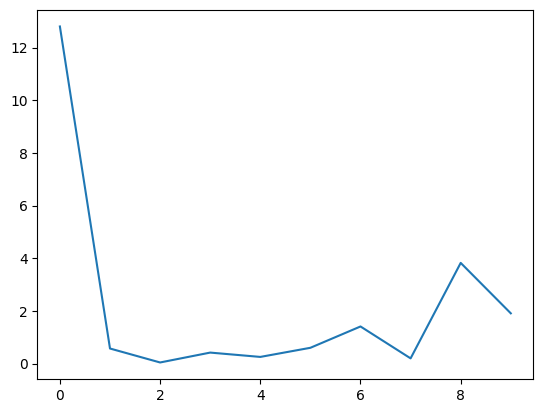

In [24]:
import matplotlib.pyplot as plt

plt.plot(losses)

In [26]:
!pip install mlflow
!pip install dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [34]:
import mlflow
os.environ["DAGSHUB_API_TOKEN"]="0c7187da66e2e96ef3f0f1b3ce752da6ca9c3122"
mlflow.set_tracking_uri("https://dagshub.com/vanshsharma7832/ML-Learner.mlflow")
mlflow.set_experiment("Resume Score")

2026/03/27 13:19:42 INFO mlflow.tracking.fluent: Experiment with name 'Resume Score' does not exist. Creating a new experiment.


MlflowException: API request to endpoint /api/2.0/mlflow/experiments/create failed with error code 403 != 200. Response body: ''

In [48]:
import dagshub
dagshub.init(repo_owner='vanshsharma7832', repo_name='ML-Learner', mlflow=True)

import mlflow

# Load the best state_dict into the model before logging
model.load_state_dict(best_model)

with mlflow.start_run():
    # params
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("batch_size", 8)
    mlflow.log_param("optimizer", "AdamW")
    mlflow.log_param("loss_fn", "MSELoss")

    # metrics (example: final loss)
    mlflow.log_metric("final_loss", losses[-1])
    mlflow.log_metric("best_loss",curr_loss)

    # model info as a param or tag (string only)
    mlflow.log_param("model_architecture", model.__class__.__name__)

    # save and log artifacts
    # mlflow.log_artifact("best_model.pt")          # file already saved earlier

    mlflow.pytorch.log_model(
        pytorch_model=model, # Now 'model' contains the best weights and is a torch.nn.Module
        artifact_path="pytorch_model",  # Folder name in artifacts
        registered_model_name="JobSimilarity"  # Auto-register if given
      )
    mlflow.log_artifact("final_data.csv")
    plt.figure()
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.savefig("losses_chart.png")
    plt.close()

    mlflow.log_artifact("losses_chart.png")

Initialized MLflow to track repo "vanshsharma7832/ML-Learner"

Repository vanshsharma7832/ML-Learner initialized!

2026/03/27 13:39:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 13:39:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/27 13:40:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/27 13:40:14 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+c

🏃 View run stately-ox-598 at: https://dagshub.com/vanshsharma7832/ML-Learner.mlflow/#/experiments/0/runs/0e3d0c91b9534a8d8391ab7d2ac1380a
🧪 View experiment at: https://dagshub.com/vanshsharma7832/ML-Learner.mlflow/#/experiments/0


In [49]:
def predict_similar_score(sample):
  model.eval()
  with torch.no_grad():
    text,labels=prepare_input(sample)
    enc=tokenize(text)
    input_ids=enc['input_ids'].to(device)
    attention_mask=enc['attention_mask'].to(device)
    output=model(input_ids,attention_mask)
    return output.cpu().numpy()

In [51]:
predict_similar_score(df.iloc[0])

array([[6.487317, 5.099057]], dtype=float32)